In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import copy
import random
import os
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. DETERMINISTIC SEEDING
# ==========================================
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)



In [ ]:
# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
print("Loading and preprocessing dataset...")

SPPED_PATH = "'./data/speed_matrix_2015_5mph'"
speed_df = pd.read_pickle(SPEED_PATH)
speed_matrix_np = speed_df.to_numpy()

data_min = np.min(speed_matrix_np)
data_max = np.max(speed_matrix_np)

speed_matrix_scaled = (speed_matrix_np - data_min) / (data_max - data_min)

def create_sliding_windows(data, window_size=12, horizon=1):

    x_offsets = np.arange(window_size)
    y_offsets = np.arange(window_size, window_size + horizon)

    num_samples = data.shape[0] - window_size - horizon + 1

    X, Y = [], []

    for t in range(num_samples):
        X.append(data[t + x_offsets, :])
        Y.append(data[t + y_offsets, :])

    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(Y), dtype=torch.float32)


X_full, Y_full = create_sliding_windows(speed_matrix_scaled)


def apply_missing_data_mask(X, missing_rate):

    if missing_rate == 0.0:
        return X

    mask = (torch.rand(X.shape) > missing_rate).float()

    return X * mask


rates = [0.0, 0.1, 0.2, 0.4, 0.8]

scenarios = {f"missing_{int(r*100)}": apply_missing_data_mask(X_full, r) for r in rates}



In [ ]:
# ==========================================
# 2. PAPER ARCHITECTURE
# ==========================================
class PaperBaselineModel(nn.Module):

    def __init__(self, nodes=323, hid_dim=128):

        super().__init__()

        self.imputer_bilstm = nn.LSTM(
            input_size=nodes,
            hidden_size=hid_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.forecaster_lstm = nn.LSTM(
            input_size=hid_dim * 2,
            hidden_size=hid_dim * 2,
            num_layers=1,
            batch_first=True
        )

        self.decoder = nn.Linear(hid_dim * 2, nodes)


    def forward(self, x):

        x, _ = self.imputer_bilstm(x)

        x, _ = self.forecaster_lstm(x)

        out = self.decoder(x[:, -1, :])

        return out.unsqueeze(1)

In [ ]:
# ==========================================
# 3. LOSS FUNCTIONS
# ==========================================
def masked_mse_loss(preds, targets, null_val=0.0):

    mask = (targets != null_val).float()

    loss = (preds - targets) ** 2

    return torch.mean(loss * mask) / (torch.mean(mask) + 1e-5)


def calculate_metrics(preds, targets, null_val=0.0):

    mask = (targets != null_val).float()

    mask /= torch.mean(mask)

    mask = torch.where(torch.isnan(mask), torch.zeros_like(mask), mask)

    mae = torch.mean(torch.abs(preds - targets) * mask)

    rmse = torch.sqrt(torch.mean(((preds - targets) ** 2) * mask))

    mape = torch.mean(torch.abs((preds - targets) / (targets + 1e-5)) * mask) * 100

    return mae.item(), rmse.item(), mape.item()


class EarlyStopping:

    def __init__(self, patience=5):

        self.patience = patience

        self.counter = 0

        self.best_loss = float('inf')

        self.early_stop = False

        self.best_state = None


    def __call__(self, val_mse, model):

        if val_mse < self.best_loss - 1e-5:

            self.best_loss = val_mse

            self.counter = 0

            self.best_state = copy.deepcopy(model.state_dict())

        else:

            self.counter += 1

            if self.counter >= self.patience:
                self.early_stop = True



In [ ]:
# ==========================================
# 4. TRAINING LOOP
# ==========================================
print("\nInitializing Paper Baseline Training (Pure MSE)...")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

epochs = 100
BATCH_SIZE = 128

columns = ['MAE', 'RMSE', 'MAPE (%)', 'GT_STD', 'Pred_STD', 'STD_Ratio']

results_df = pd.DataFrame(index=scenarios.keys(), columns=columns)

scenario_predictions = {}

Y_test_real_plot = None


for exp_name, X_masked in scenarios.items():

    print(f"\n{'='*40}\nSCENARIO: {exp_name.upper()}\n{'='*40}")

    split_idx = int(len(X_masked) * 0.8)

    X_train = X_masked[:split_idx].to(device)
    Y_train = Y_full[:split_idx].to(device)

    X_test = X_masked[split_idx:].to(device)
    Y_test = Y_full[split_idx:].to(device)

    model = PaperBaselineModel().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

    early_stopper = EarlyStopping(patience=4)

    for epoch in range(epochs):

        model.train()

        for i in range(0, len(X_train), BATCH_SIZE):

            batch_X = X_train[i:i+BATCH_SIZE]
            batch_Y = Y_train[i:i+BATCH_SIZE]

            optimizer.zero_grad()

            preds = model(batch_X)

            loss = masked_mse_loss(preds, batch_Y)

            loss.backward()

            optimizer.step()

        model.eval()

        with torch.no_grad():

            val_preds = model(X_test[:512])

            val_mse = masked_mse_loss(val_preds, Y_test[:512])

        early_stopper(val_mse.item(), model)

        print(f"Epoch {epoch+1}/{epochs} | Val Masked MSE: {val_mse.item():.5f}")

        if early_stopper.early_stop:
            print("Early stopping triggered.")
            break

    model.load_state_dict(early_stopper.best_state)

    model.eval()

    all_preds = []

    with torch.no_grad():

        for i in range(0, len(X_test), BATCH_SIZE):

            batch_preds_scaled = model(X_test[i:i+BATCH_SIZE])

            all_preds.append(batch_preds_scaled)

        test_preds_scaled = torch.cat(all_preds, dim=0)

        test_preds = (test_preds_scaled * (data_max - data_min)) + data_min

        Y_test_real = (Y_test * (data_max - data_min)) + data_min

        scenario_predictions[exp_name] = test_preds.cpu().numpy()

        if Y_test_real_plot is None:
            Y_test_real_plot = Y_test_real.cpu().numpy()

        mae, rmse, mape = calculate_metrics(test_preds, Y_test_real)

        # ===============================
        # STANDARD DEVIATION ANALYSIS
        # ===============================
        pred_std = torch.std(test_preds).item()
        true_std = torch.std(Y_test_real).item()
        std_ratio = pred_std / (true_std + 1e-8)

    results_df.loc[exp_name] = [
        round(mae,3),
        round(rmse,3),
        round(mape,3),
        round(true_std,3),
        round(pred_std,3),
        round(std_ratio,3)
    ]

print("\nFINAL RESULTS")
print(results_df)

In [ ]:
# ==========================================
# 5. TRAFFIC VISUALIZATION
# ==========================================
sns.set_theme(style="whitegrid")

sensor_idx = 10

y_true_full = Y_test_real_plot[:, 0, sensor_idx]

x_axis = np.arange(len(y_true_full))

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(18,16), sharex=True)

scenario_names = list(scenario_predictions.keys())

for i, ax in enumerate(axes):

    exp_name = scenario_names[i]

    y_pred_full = scenario_predictions[exp_name][:, 0, sensor_idx]

    ax.plot(x_axis, y_true_full, label='Ground Truth', linewidth=1.5)

    ax.plot(x_axis, y_pred_full, label=f'Prediction ({exp_name})', linewidth=1)

    ax.set_ylim(0,80)

    ax.set_ylabel('Speed (mph)')

    ax.set_title(exp_name)

    ax.legend()

    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time Steps')

plt.tight_layout()

plt.show()


In [ ]:
# ==========================================
# 6. STD COMPARISON VISUALIZATION
# ==========================================
print("\nPlotting STD comparison...")

scenes = results_df.index.tolist()

gt_std = results_df['GT_STD'].astype(float).values

pred_std = results_df['Pred_STD'].astype(float).values

x = np.arange(len(scenes))

plt.figure(figsize=(10,6))

plt.bar(x - 0.2, gt_std, width=0.4, label='Ground Truth STD')

plt.bar(x + 0.2, pred_std, width=0.4, label='Prediction STD')

plt.xticks(x, scenes)

plt.ylabel("Standard Deviation")

plt.title("Traffic Speed Variability Capture")

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

# Output from original experiment

```
# Training Logs & Results

##  Loading & Initialization
- Loading and preprocessing dataset...
- Initializing Paper Baseline Training (Pure MSE)...

---

## SCENARIO: MISSING_0
```

Epoch 1/100  | Val Masked MSE: 0.00230
Epoch 5/100  | Val Masked MSE: 0.00155
Epoch 10/100 | Val Masked MSE: 0.00122
Epoch 15/100 | Val Masked MSE: 0.00111
Epoch 20/100 | Val Masked MSE: 0.00101
Epoch 25/100 | Val Masked MSE: 0.00098
Epoch 28/100 | Val Masked MSE: 0.00097
→ Early stopping triggered

```

---

## SCENARIO: MISSING_10
```

Epoch 1/100  | Val Masked MSE: 0.00235
Epoch 5/100  | Val Masked MSE: 0.00177
Epoch 10/100 | Val Masked MSE: 0.00154
Epoch 15/100 | Val Masked MSE: 0.00145
Epoch 20/100 | Val Masked MSE: 0.00135
Epoch 25/100 | Val Masked MSE: 0.00134
Epoch 28/100 | Val Masked MSE: 0.00134
→ Early stopping triggered

```

---

##  SCENARIO: MISSING_20
```

Epoch 1/100  | Val Masked MSE: 0.00241
Epoch 5/100  | Val Masked MSE: 0.00185
Epoch 10/100 | Val Masked MSE: 0.00164
Epoch 15/100 | Val Masked MSE: 0.00154
Epoch 20/100 | Val Masked MSE: 0.00146
Epoch 25/100 | Val Masked MSE: 0.00146
Epoch 28/100 | Val Masked MSE: 0.00143
→ Early stopping triggered

```

---

## SCENARIO: MISSING_40
```

Epoch 1/100  | Val Masked MSE: 0.00249
Epoch 5/100  | Val Masked MSE: 0.00204
Epoch 10/100 | Val Masked MSE: 0.00181
Epoch 15/100 | Val Masked MSE: 0.00176
Epoch 20/100 | Val Masked MSE: 0.00170
Epoch 25/100 | Val Masked MSE: 0.00165
Epoch 29/100 | Val Masked MSE: 0.00168
→ Early stopping triggered

```

---

## SCENARIO: MISSING_80
```

Epoch 1/100  | Val Masked MSE: 0.00310
Epoch 5/100  | Val Masked MSE: 0.00238
Epoch 10/100 | Val Masked MSE: 0.00222
Epoch 15/100 | Val Masked MSE: 0.00211
Epoch 20/100 | Val Masked MSE: 0.00205
Epoch 25/100 | Val Masked MSE: 0.00204
Epoch 30/100 | Val Masked MSE: 0.00210
→ Early stopping triggered

```

---

##  FINAL RESULTS

| Scenario    | MAE   | RMSE  | MAPE (%) | GT_STD | Pred_STD | STD_Ratio |
|------------|-------|-------|----------|--------|----------|----------|
| missing_0  | 3.384 | 4.848 | 8.749    | 13.202 | 12.189   | 0.923    |
| missing_10 | 3.882 | 5.733 | 10.503   | 13.202 | 11.771   | 0.892    |
| missing_20 | 4.030 | 6.014 | 11.024   | 13.202 | 11.924   | 0.903    |
| missing_40 | 4.208 | 6.391 | 12.042   | 13.202 | 11.508   | 0.872    |
| missing_80 | 4.656 | 7.136 | 13.664   | 13.202 | 11.113   | 0.842    |

---

## Notes
- Performance degrades as missing data increases.
- STD ratio consistently < 1 → model underestimates variance.
- Early stopping triggered in all scenarios.
- Plotting STD comparison...
```


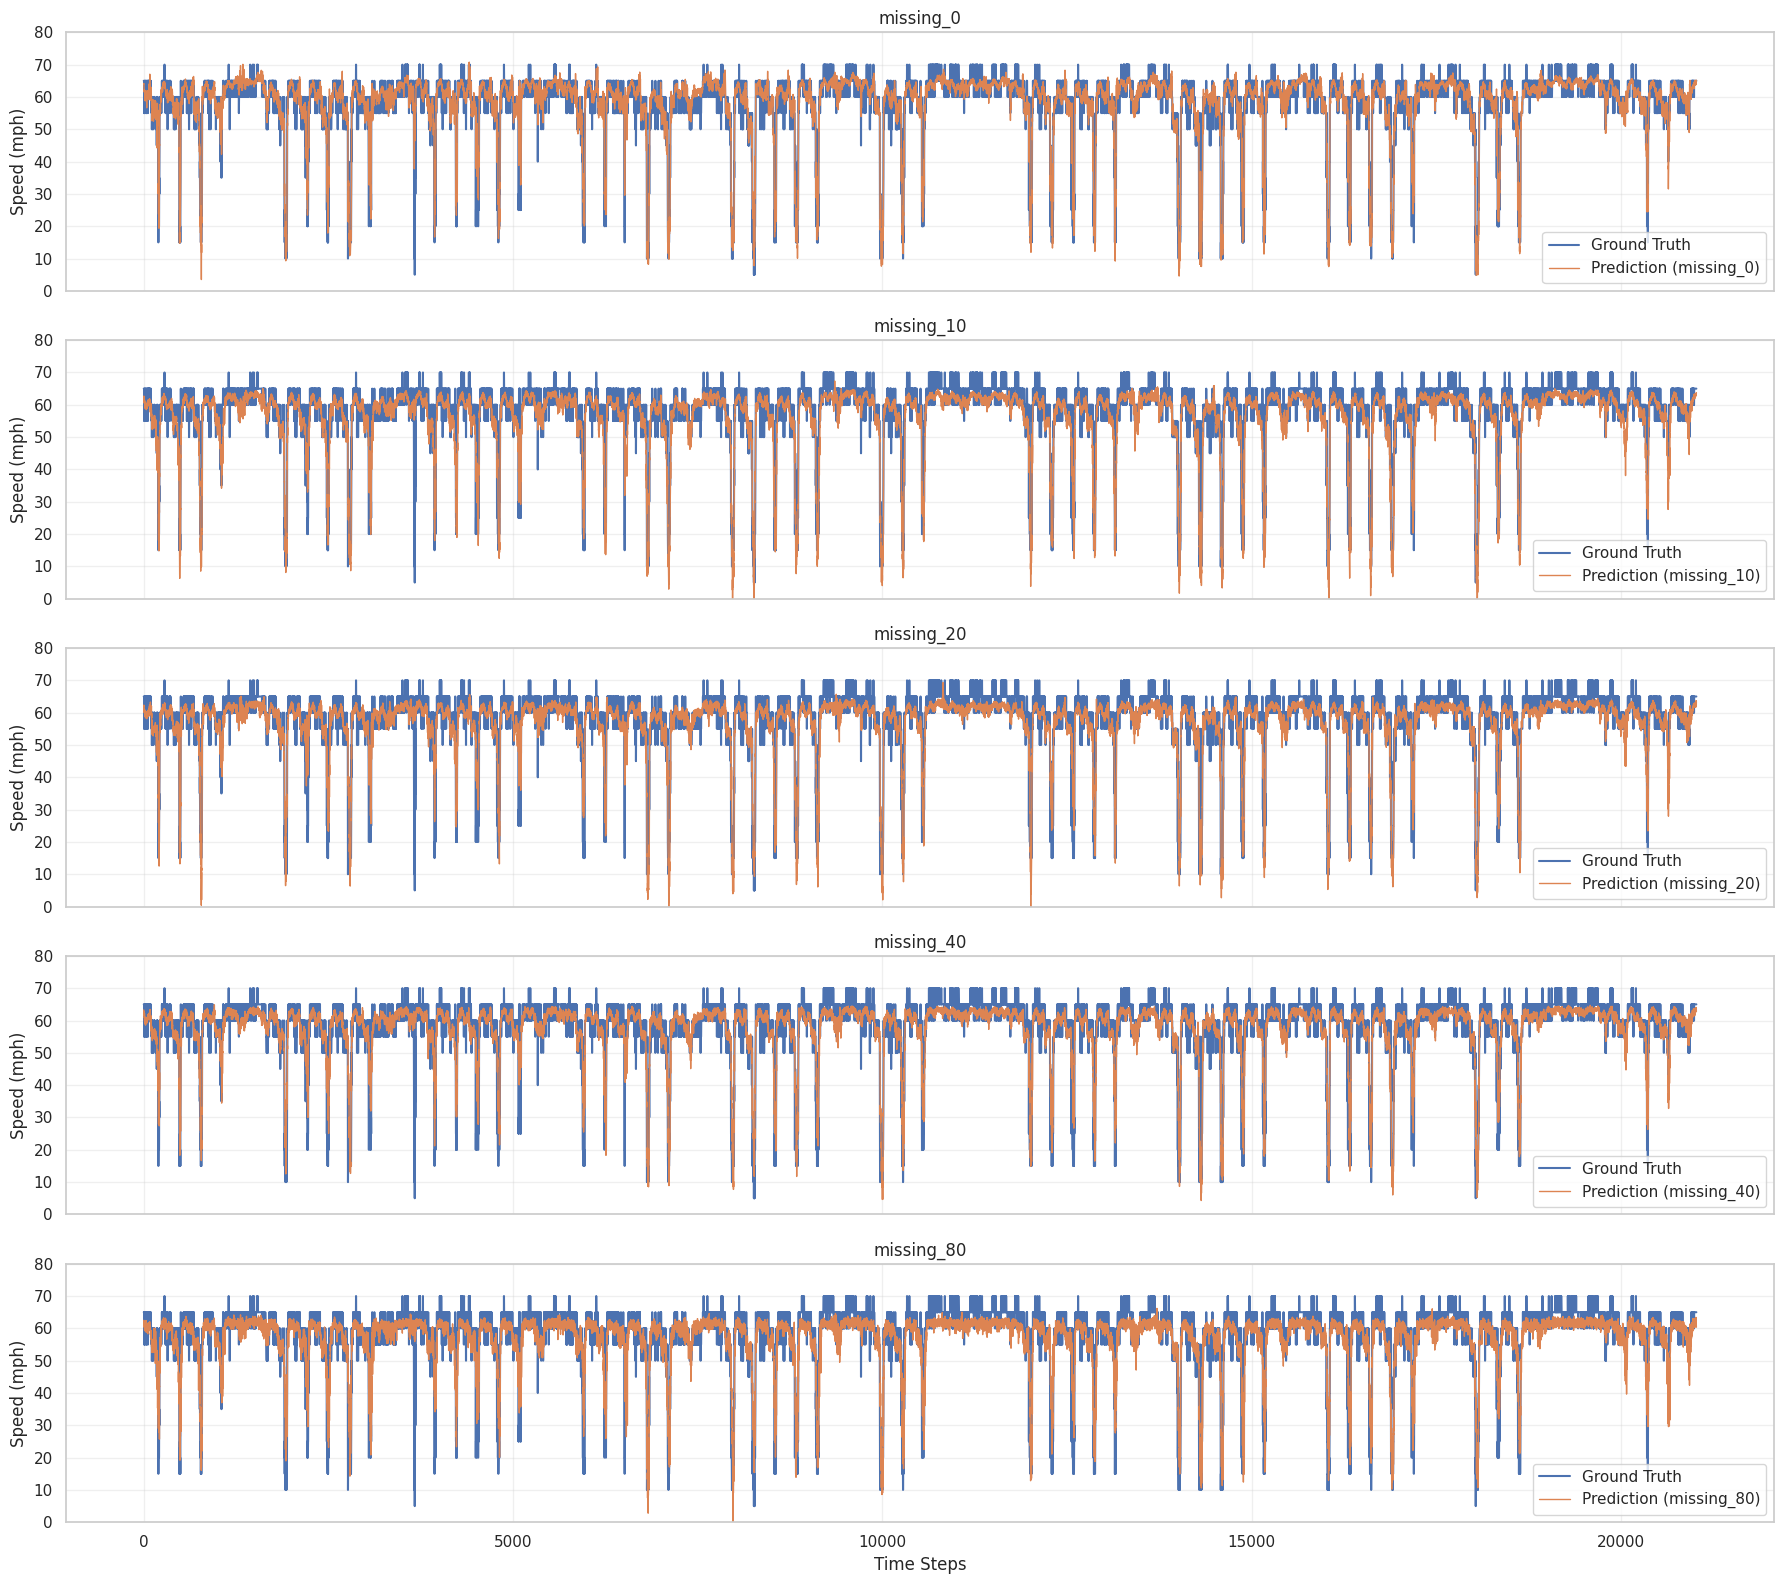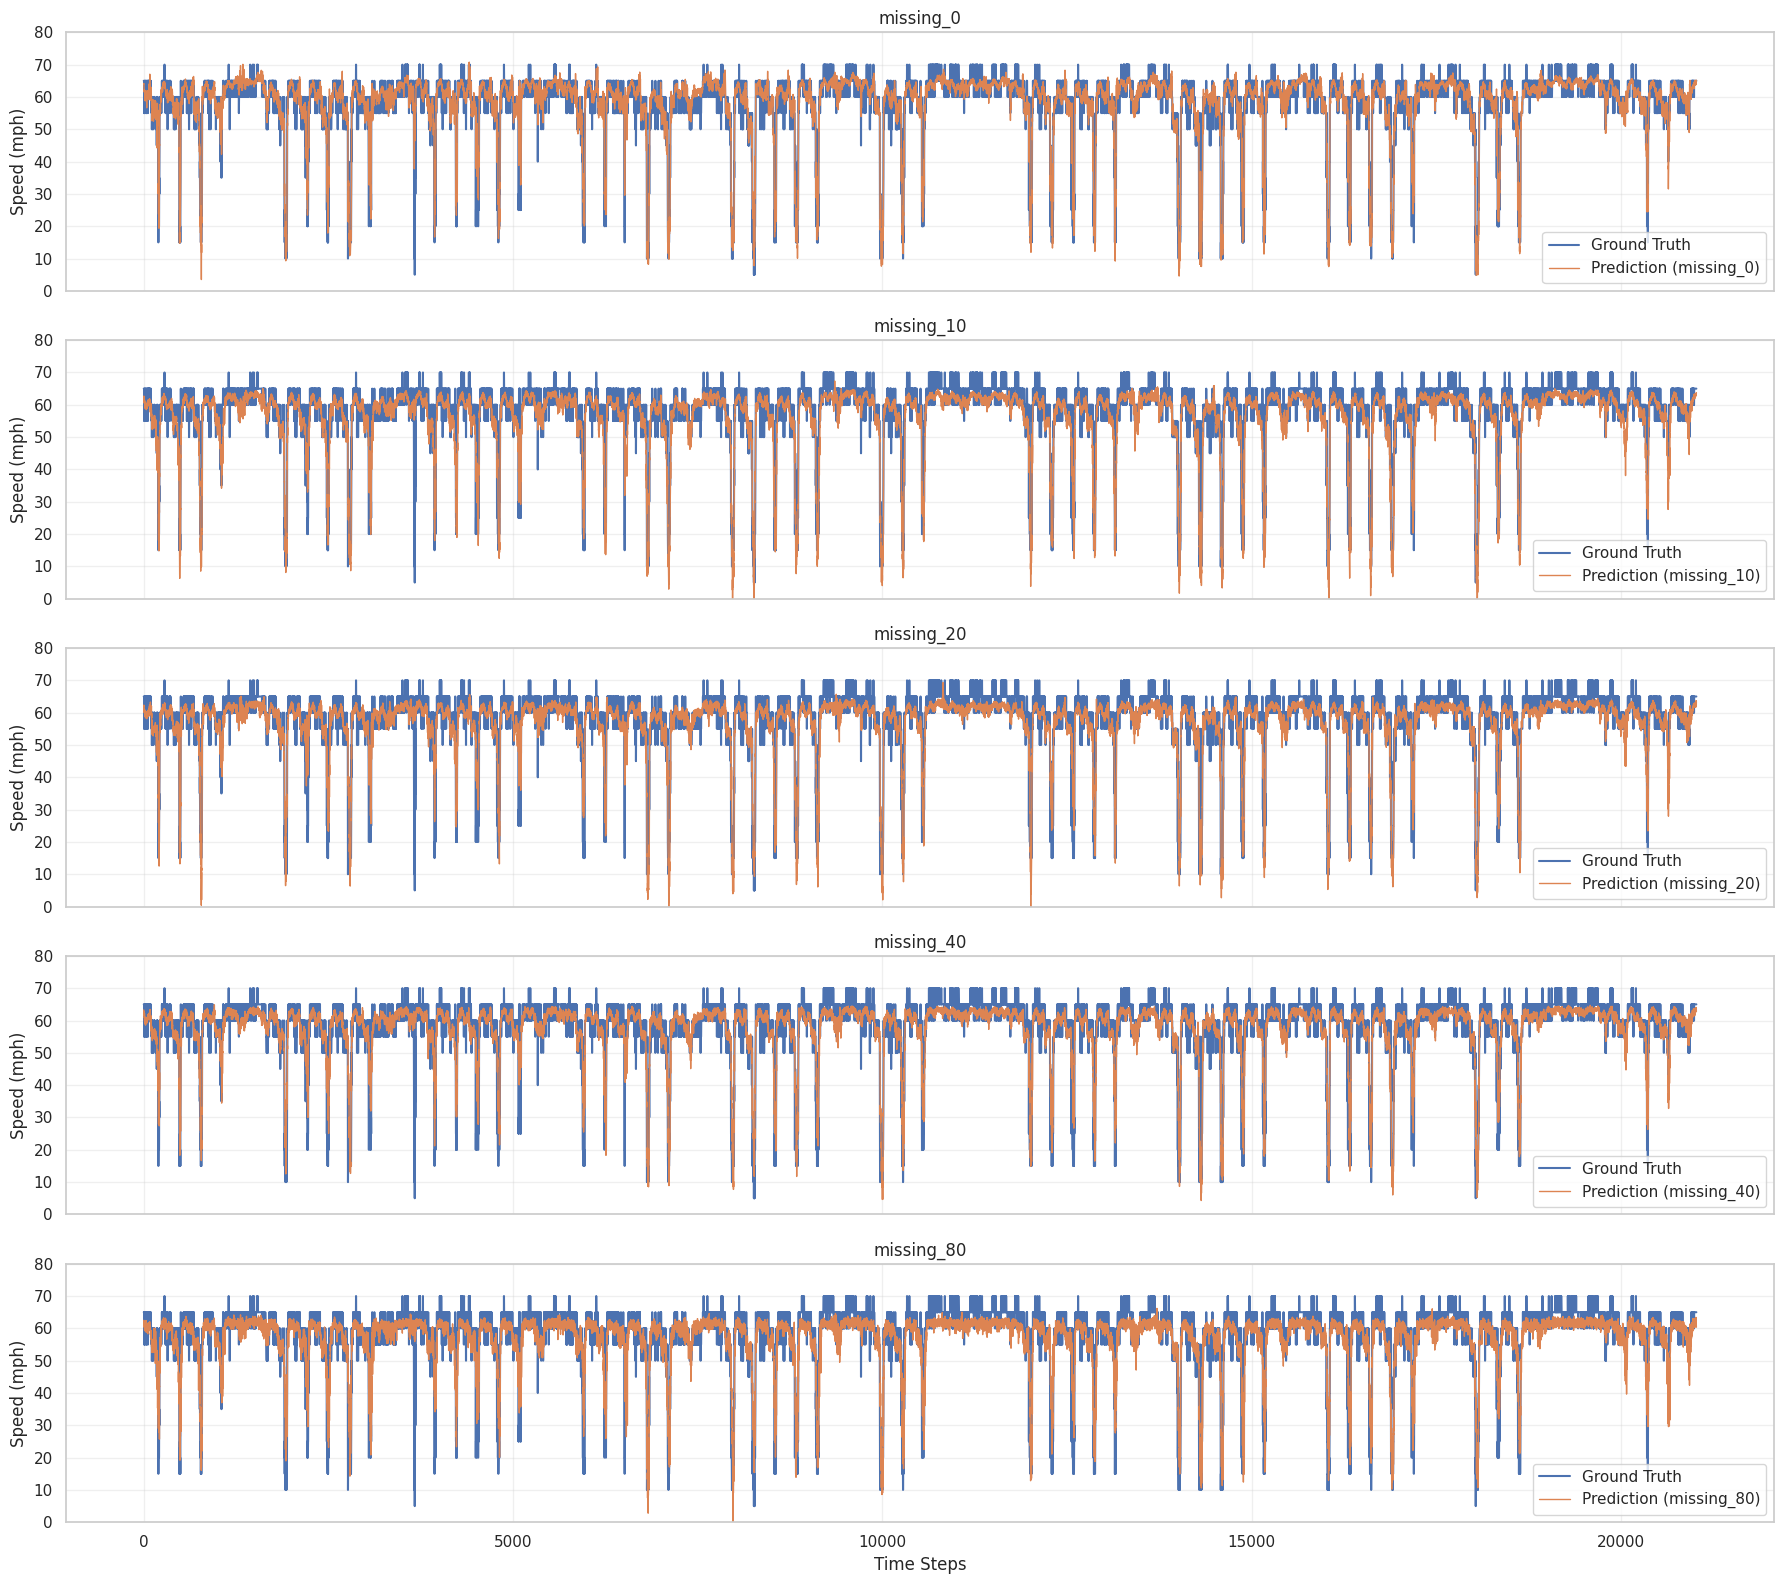